# 10 — Policy Gradients and REINFORCE (Deep Reinforcement Learning)

**From the policy-gradient derivation to line-by-line updates, probabilities and learning curves**  
It explains **policy gradients, the log-derivative trick, trajectory probabilities, gradient ascent, REINFORCE, and on-policy training** and then works through **two complete, five-state episodes in each of two examples**:

1. **Example A — 2 available actions:** Right / Left; four decisions per episode; sigmoid policy.
2. **Example B — 4 available actions:** Up / Down / Left / Right; four decisions per episode; softmax policy.


## 1. Where policy gradients fit in deep reinforcement learning

| Aspect | Value-based methods | Policy-based methods |
|---|---|---|
| What is learned? | Action values $Q(s,a)$ or state values $V(s)$ | Direct policy $\pi_\theta(a\mid s)$ |
| How are actions picked? | Often greedy or $\epsilon$-greedy from values | Sample from the learned policy or use a deterministic actor |
| Typical methods | Q-learning, DQN, Double DQN | REINFORCE; policy component of PPO, A2C and A3C |
| Continuous actions | Maximizing over all actions can be difficult | Gaussian or deterministic policy can output continuous actions directly |

**Model-based vs. model-free:** Model-based methods use or learn an environment model. Model-free methods learn from experience without planning through an explicit model. REINFORCE is **model-free**. Actor–critic methods such as A2C, PPO, DDPG, and SAC combine a policy with a learned value function; they do not all belong exclusively to one simple “Q-learning versus policy” branch.

**Important:** Policy-gradient methods can use a value function as a baseline or critic. A value function is **not required** for choosing actions under the basic policy parameterization in REINFORCE.

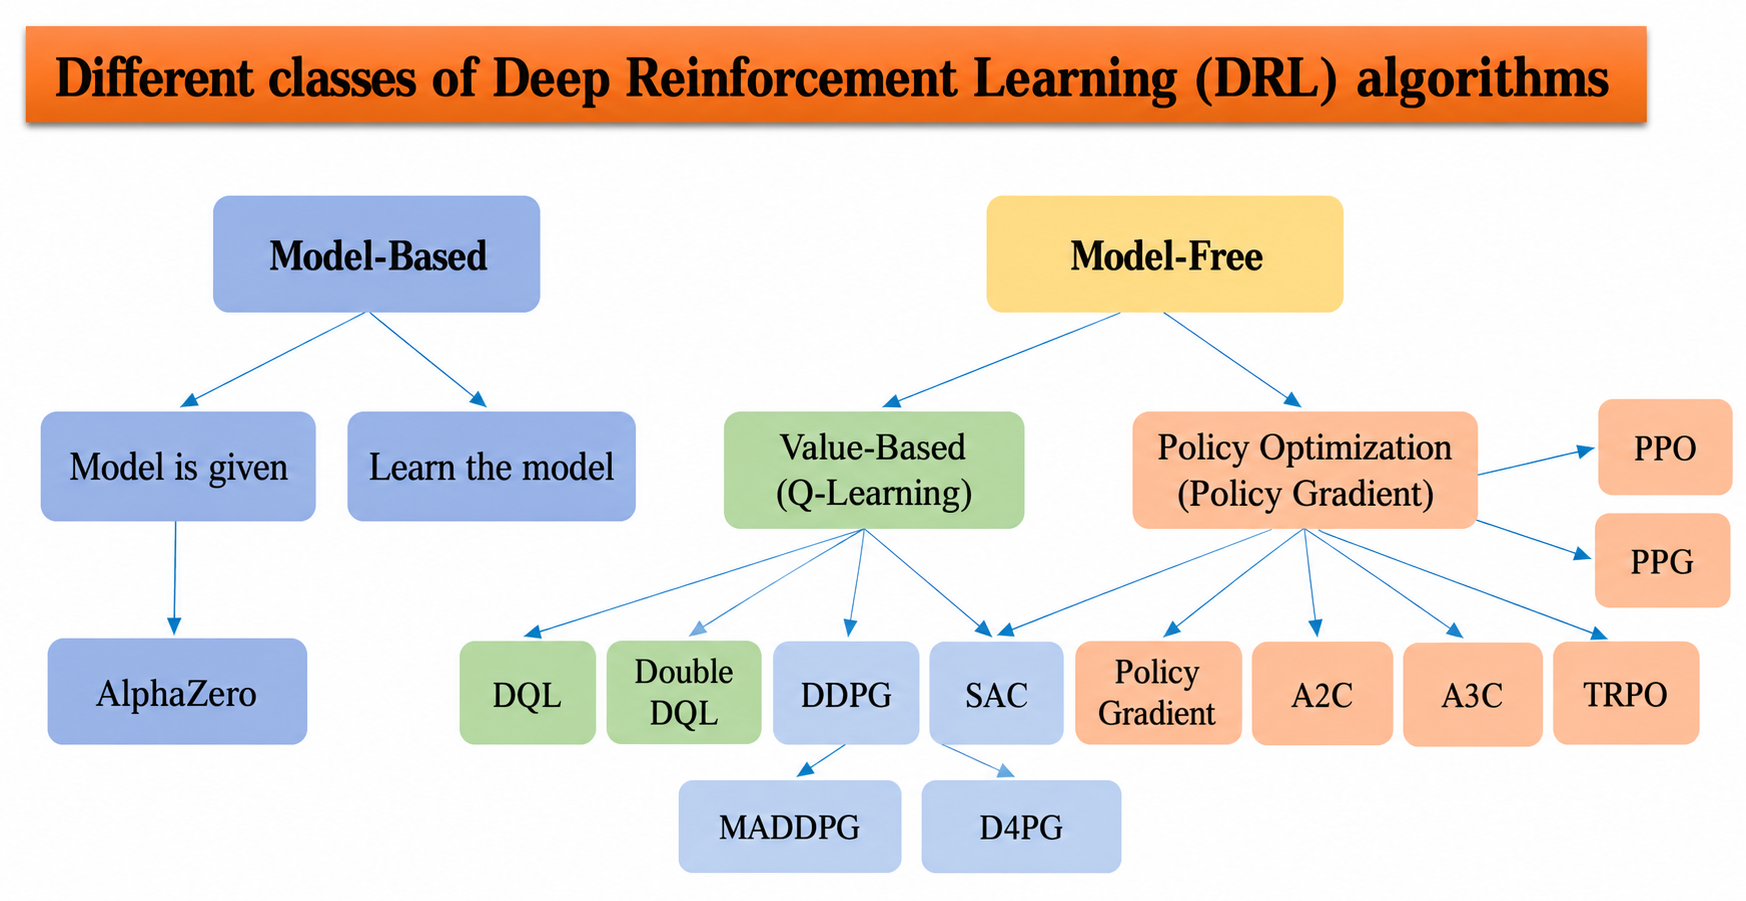

## 2. Basic notation and objective

An episode with **five visited states and four decisions** is

$$\tau=(S_0,A_0,R_1,S_1,A_1,R_2,S_2,A_2,R_3,S_3,A_3,R_4,S_4),\qquad S_4=\text{terminal}.$$

Use $R_{t+1}$ for the reward **received after** taking $A_t$ in $S_t$; $T=4$ is the number of decisions. The return from time $t$ is

$$\boxed{G_t=\sum_{k=t}^{T-1}\gamma^{k-t}R_{k+1}=R_{t+1}+\gamma G_{t+1}},\qquad G_T=0.$$

The **discounted episodic objective** is

$$\boxed{J(\theta)=\mathbb E_{\tau\sim p_\theta(\tau)}[G_0]=\mathbb E\!\left[\sum_{t=0}^{T-1}\gamma^tR_{t+1}\right]}.$$

Here $\theta$ denotes policy parameters (neural-network weights in a typical DRL implementation), $\pi_\theta(a\mid s)$ denotes an action probability, $\gamma\in[0,1]$ denotes discounting, and $\alpha>0$ denotes the learning rate.

**Gradient ascent** maximizes $J$: $\boxed{\theta\leftarrow\theta+\alpha\nabla_\theta J(\theta)}$. In software minimizing a loss, use $L=-J$ (or a sampled policy-loss surrogate) instead.

### How to read the four-step trajectory

| Time step | Current state | Selected action | Reward received | Next state |
|---:|---|---|---|---|
| $t=0$ | $S_0$ | $A_0$ | $R_1$ | $S_1$ |
| $t=1$ | $S_1$ | $A_1$ | $R_2$ | $S_2$ |
| $t=2$ | $S_2$ | $A_2$ | $R_3$ | $S_3$ |
| $t=3$ | $S_3$ | $A_3$ | $R_4$ | $S_4$ (terminal) |

**Two easy-to-confuse numbers:** $t$ labels the **decision**; $R_{t+1}$ labels the **reward received after that decision**. A five-state trajectory has **four actions**, and this is true even when **four different actions are available** at each decision. The discount weights are $\gamma^0=1$, $\gamma^1=0.9$, $\gamma^2=0.81$, $\gamma^3=0.729$.

## 3. Deriving the REINFORCE policy gradient — every step

### 3.1 Convert the expectation into a trajectory sum

$$J(\theta)=\sum_\tau p_\theta(\tau)G_0(\tau).$$

Differentiate (the reward sequence on a **fixed trajectory** does not explicitly depend on $\theta$):

$$\nabla_\theta J(\theta)=\sum_\tau G_0(\tau)\nabla_\theta p_\theta(\tau).$$

### 3.2 Log-derivative trick

From calculus: $\nabla_\theta\log p_\theta(\tau)=\nabla_\theta p_\theta(\tau)/p_\theta(\tau)$, so

$$\boxed{\nabla_\theta p_\theta(\tau)=p_\theta(\tau)\nabla_\theta\log p_\theta(\tau)}.$$

Substitute and rewrite the probability-weighted sum as an expectation:

$$\boxed{\nabla_\theta J(\theta)=\mathbb E_{\tau\sim p_\theta}\left[G_0\nabla_\theta\log p_\theta(\tau)\right]}.$$

This converts **the derivative of a probability** into **the derivative of a log probability**; it is not merely a numerical trick to prevent exponentiation.

### 3.3 Factor the probability of a trajectory

For an initial-state distribution $\rho$ and environment transition/reward model $P$,

$$p_\theta(\tau)=\rho(S_0)\prod_{t=0}^{T-1}\pi_\theta(A_t\mid S_t)P(S_{t+1},R_{t+1}\mid S_t,A_t).$$

Taking logs converts the product into a sum:

$$\log p_\theta(\tau)=\log\rho(S_0)+\sum_{t=0}^{T-1}\log\pi_\theta(A_t\mid S_t)+\sum_{t=0}^{T-1}\log P(S_{t+1},R_{t+1}\mid S_t,A_t).$$

Assuming the **environment** and **initial-state distribution** are independent of policy parameters $\theta$, their **direct** derivatives vanish:

$$\boxed{\nabla_\theta\log p_\theta(\tau)=\sum_{t=0}^{T-1}\nabla_\theta\log\pi_\theta(A_t\mid S_t)}.$$

**Why this matters:** We still sample from a state distribution that changes when the policy changes; we simply do **not need to differentiate the unknown environment transitions**.

### 3.4 Why replace $G_0$ by the future return $G_t$?

Substitute the trajectory result:

$$\nabla_\theta J(\theta)=\mathbb E\left[\sum_{t=0}^{T-1}G_0\nabla_\theta\log\pi_\theta(A_t\mid S_t)\right].$$

For each $t$, separate earlier rewards from future rewards:

$$G_0=\underbrace{\sum_{k=0}^{t-1}\gamma^kR_{k+1}}_{\text{past rewards}}+\gamma^t\underbrace{\sum_{k=t}^{T-1}\gamma^{k-t}R_{k+1}}_{G_t}.$$

Earlier rewards do not depend on the **action yet to be drawn** at time $t$. The expected log-policy gradient conditioned on the state is zero:

$$\mathbb E_{A_t\sim\pi_\theta}[\nabla_\theta\log\pi_\theta(A_t\mid S_t)]=\sum_a\pi_\theta(a\mid S_t)\nabla_\theta\log\pi_\theta(a\mid S_t)=\nabla_\theta\sum_a\pi_\theta(a\mid S_t)=0.$$

Thus all past-reward terms have **zero expectation**, giving the exact discounted policy-gradient expression:

$$\boxed{\nabla_\theta J(\theta)=\mathbb E\left[\sum_{t=0}^{T-1}\gamma^tG_t\nabla_\theta\log\pi_\theta(A_t\mid S_t)\right]}.$$

**One-episode Monte Carlo estimate:**

$$\boxed{\widehat{\nabla_\theta J}=\sum_{t=0}^{T-1}\gamma^tG_t\nabla_\theta\log\pi_\theta(A_t\mid S_t)}.$$

**Why is $\gamma^t$ present?** The slide with $\sum_tG_t\nabla\log\pi$ is often shown as a simplified illustration. For **the discounted start-state objective defined above**, the outside $\gamma^t$ is needed. Both formulas coincide when $\gamma=1$;

**One-episode parameter update:**

$$\boxed{\theta\leftarrow\theta+\alpha\sum_{t=0}^{T-1}\gamma^tG_t\nabla_\theta\log\pi_\theta(A_t\mid S_t)}.$$

The gradient is *estimated* from trajectories; we do not compute the exact expectation over every possible trajectory.

### 3.5 Derivation in one compact chain (for revision)

$$J(\theta)=\sum_\tau p_\theta(\tau)G_0\quad\Rightarrow\quad \nabla_\theta J=\sum_\tau G_0\nabla_\theta p_\theta(\tau)\quad\Rightarrow\quad \mathbb E[G_0\nabla_\theta\log p_\theta(\tau)].$$

$$\nabla_\theta\log p_\theta(\tau)=\sum_{t=0}^{T-1}\nabla_\theta\log\pi_\theta(A_t\mid S_t)\quad\Rightarrow\quad\boxed{\nabla_\theta J=\mathbb E\left[\sum_{t=0}^{T-1}\gamma^tG_t\nabla_\theta\log\pi_\theta(A_t\mid S_t)\right]}.$$

The expectation averages over possible trajectories; **a single complete episode** supplies a noisy Monte Carlo estimate. **The policy gradient is a vector** in general. In Example A it has one nonzero component at the visited state; in Example B it has four nonzero logit components at that state.

## 4. REINFORCE algorithm (episodic Monte Carlo control)
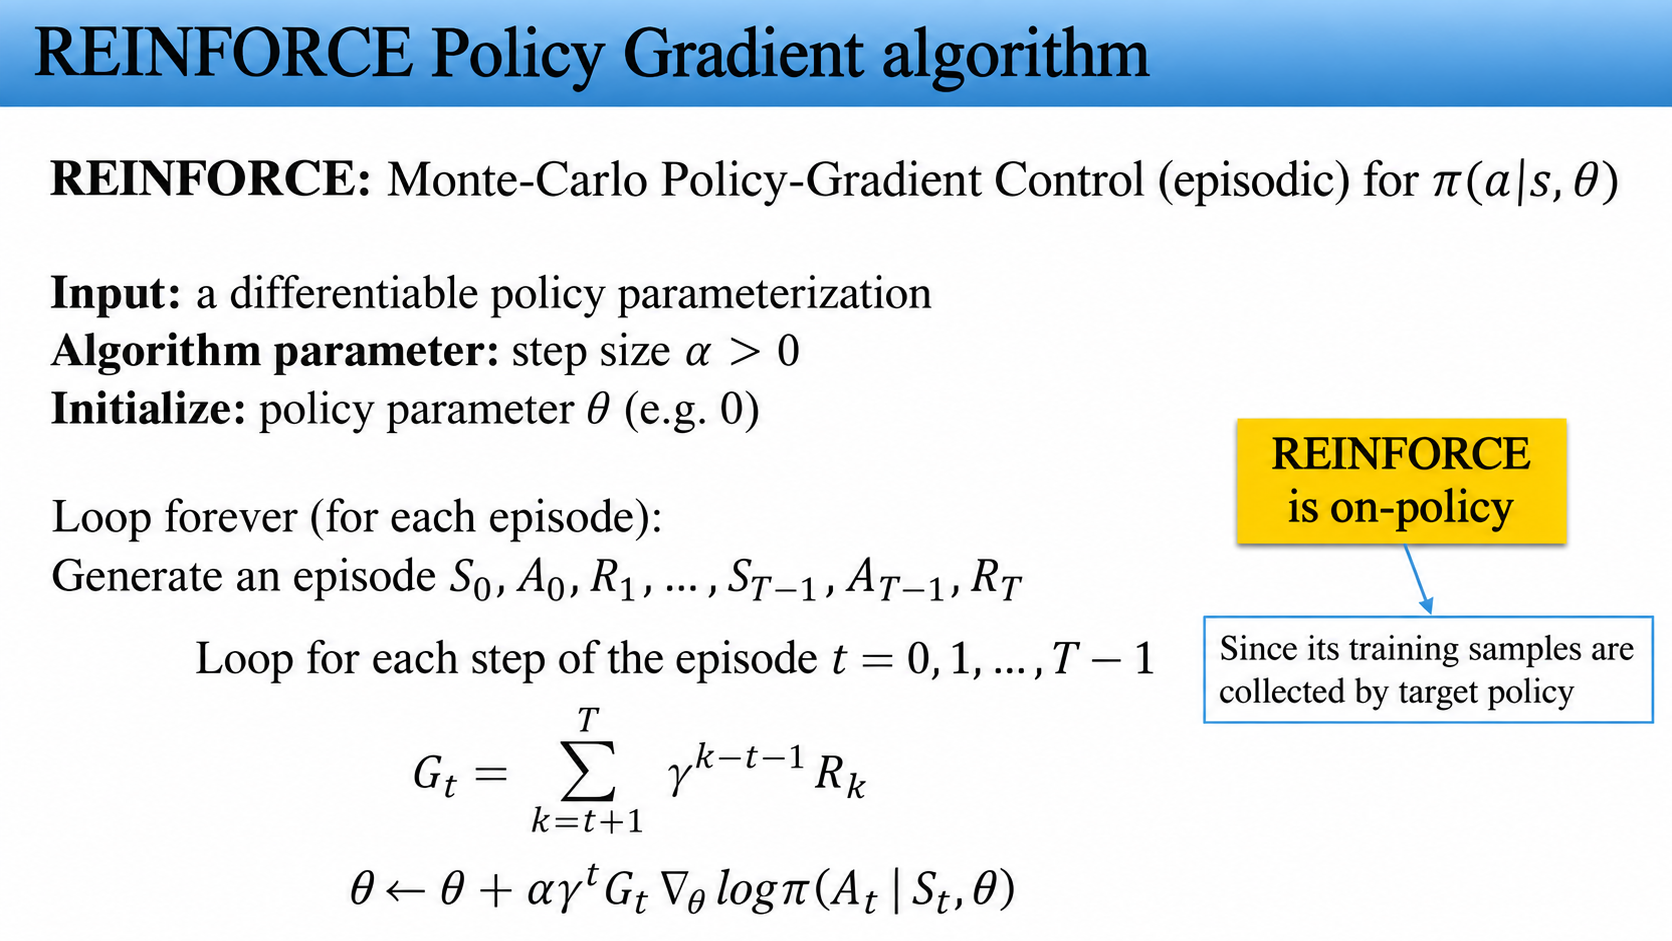
```text
Input: Differentiable policy πθ(a|s), α > 0, discount γ
Initialize policy parameters θ
Repeat for each episode:
    1. Roll out πθ and store (S0,A0,R1,...,ST) until terminal.
    2. Calculate Gt backward using Gt = R(t+1) + γ G(t+1).
    3. For every step t = 0,...,T-1, calculate γ^t Gt ∇θ log πθ(At|St).
    4. Sum sampled gradients and apply θ ← θ + α (gradient sum).
    5. Generate the next episode from the updated policy.
```

- **Monte Carlo:** Uses sampled **complete** episode returns, not a bootstrap from $V(S_{t+1})$.
- **On-policy:** The learning episode is generated by the current policy $\pi_\theta$.
- **What happens during an episode?** Collect actions and rewards **first**; update **after** termination.
- **Shared neural network:** Calculate the episode's gradients from the policy that generated it, **aggregate**, then update once. Our manual examples use a separate parameter vector at each nonterminal state, so displaying four state-specific updates after the episode is mathematically equivalent.

> **Interpretation of plots:** In the deliberately chosen manual trajectories, the exact expected return increases after each parameter update. General stochastic REINFORCE does **not** guarantee a monotonic improvement after each update or episode.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ALPHA = 0.10
GAMMA = 0.90
SEED = 42
np.set_printoptions(precision=4, suppress=True)
pd.set_option('display.precision', 5)

STATES = ['S0', 'S1', 'S2', 'S3']
TERMINAL = 'S4'


def discounted_returns(rewards, gamma=GAMMA):
    """Gt = R(t+1) + gamma G(t+1), calculated backward."""
    g = 0.0
    result = np.zeros(len(rewards), dtype=float)
    for t in reversed(range(len(rewards))):
        g = float(rewards[t]) + gamma * g
        result[t] = g
    return result


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def softmax(z):
    z = np.asarray(z, dtype=float)
    exp_z = np.exp(z - np.max(z, axis=-1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=-1, keepdims=True)

print('Setup: 5 visited states, 4 decisions, alpha =', ALPHA, ', gamma =', GAMMA)

Setup: 5 visited states, 4 decisions, alpha = 0.1 , gamma = 0.9


---
# Example A — Two available actions (Right, Left)

## 5. Environment, policy and gradient

We use five sequential states, with **four decisions**:

$$S_0\xrightarrow{A_0,R_1}S_1\xrightarrow{A_1,R_2}S_2\xrightarrow{A_2,R_3}S_3\xrightarrow{A_3,R_4}S_4\;(\mathrm{terminal}).$$

Each state has two available actions: **Right** and **Left**. Actions determine rewards; the transition to the next state is deterministic for this simple calculation.

| State | Reward if Right | Reward if Left |
|---|---:|---:|
| $S_0$ | +1 | −1 |
| $S_1$ | +2 | −2 |
| $S_2$ | +1 | −1 |
| $S_3$ | +3 | −3 |

Use four **independent state parameters** $\theta=[\theta_0,\theta_1,\theta_2,\theta_3]=[0,0,0,0]$:

$$\boxed{P(R\mid S_i)=\sigma(\theta_i)=\frac{1}{1+e^{-\theta_i}}},\quad P(L\mid S_i)=1-P(R\mid S_i).$$

**Gradient derivation, Right (one line):** $\frac{\partial}{\partial\theta_i}\log\sigma(\theta_i)=\sigma'(\theta_i)/\sigma(\theta_i)=1-\sigma(\theta_i)=1-P(R\mid S_i)$.

**Gradient derivation, Left (one line):** $\frac{\partial}{\partial\theta_i}\log[1-\sigma(\theta_i)]=-\sigma(\theta_i)=-P(R\mid S_i)$.

Initially, $P(R\mid S_i)=P(L\mid S_i)=0.5000$ for all four nonterminal states.

### 5.1 Sigmoid derivative: why Right and Left have different gradients

**For Right:** $\frac{\partial}{\partial\theta_i}\log\sigma(\theta_i)=\frac{\sigma(\theta_i)(1-\sigma(\theta_i))}{\sigma(\theta_i)}=1-P(R\mid S_i)$.

**For Left:** $\frac{\partial}{\partial\theta_i}\log[1-\sigma(\theta_i)]=\frac{-\sigma(\theta_i)(1-\sigma(\theta_i))}{1-\sigma(\theta_i)}=-P(R\mid S_i)$.

**At the initial policy:** selected **Right** $\Rightarrow g_i=+0.5$; selected **Left** $\Rightarrow g_i=-0.5$. These are the **derivatives of log probabilities**, not the probabilities themselves. As the policy changes, so do the derivatives.

## 6. Example A — Episode 1: Right, Right, Right, Right

$$S_0\xrightarrow{R,+1}S_1\xrightarrow{R,+2}S_2\xrightarrow{R,+1}S_3\xrightarrow{R,+3}S_4.$$

**Returns (one calculation per line):**  
**$t=3$:** $G_3=R_4=3$.  
**$t=2$:** $G_2=R_3+0.9G_3=1+0.9(3.0000)=3.7000$.  
**$t=1$:** $G_1=R_2+0.9G_2=2+0.9(3.7000)=5.3300$.  
**$t=0$:** $G_0=R_1+0.9G_1=1+0.9(5.3300)=5.7970$.

**Prepare the updates:** With $G=[5.797,5.33,3.7,3]$ and $g_t=+0.5$ for all four initially selected Right actions, the coefficient multiplying $g_t$ is $c_t=0.1(0.9)^tG_t$. Read the four **single-line parameter updates** below; each parameter belongs to a different state.

**Update at each step (after the episode):** $\theta_i\leftarrow\theta_i+0.1(0.9)^iG_i[1-P(R\mid S_i)]$. Each row updates a **different** state parameter.

| Step | Single-line update | New $P(R\mid S_t)$ |
|---|---|---:|
| $t=0$ | $\theta_0=0.00000+0.1(1.000)(5.797)(0.5000)=0.28985$ | 0.5720 |
| $t=1$ | $\theta_1=0.00000+0.1(0.900)(5.330)(0.5000)=0.23985$ | 0.5597 |
| $t=2$ | $\theta_2=0.00000+0.1(0.810)(3.700)(0.5000)=0.14985$ | 0.5374 |
| $t=3$ | $\theta_3=0.00000+0.1(0.729)(3.000)(0.5000)=0.10935$ | 0.5273 |

### Check the action probabilities after Episode 1 (one calculation per line)

**$t=0$:** $P(R\mid S_0)=\sigma(0.28985)=1/(1+e^{-0.28985})=0.57196$; $P(L\mid S_0)=1-0.57196=0.42804$.  
**$t=1$:** $P(R\mid S_1)=\sigma(0.23985)=1/(1+e^{-0.23985})=0.55968$; $P(L\mid S_1)=1-0.55968=0.44032$.  
**$t=2$:** $P(R\mid S_2)=\sigma(0.14985)=1/(1+e^{-0.14985})=0.53739$; $P(L\mid S_2)=1-0.53739=0.46261$.  
**$t=3$:** $P(R\mid S_3)=\sigma(0.10935)=1/(1+e^{-0.10935})=0.52731$; $P(L\mid S_3)=1-0.52731=0.47269$.

Each selected Right action had a **positive return**, so its probability increased at its state.

**Interpretation:** Positive returns reinforce each Right action. The policy is still stochastic, so Left remains possible in the next episode.

## 7. Example A — Episode 2: Left, Left, Left, Left

Sample the **next** episode under the updated policy. Left still has nonzero probability:

$$S_0\xrightarrow{L,-1}S_1\xrightarrow{L,-2}S_2\xrightarrow{L,-1}S_3\xrightarrow{L,-3}S_4.$$

**Returns (one calculation per line):**  
**$t=3$:** $G_3=R_4=-3$.  
**$t=2$:** $G_2=R_3+0.9G_3=-1+0.9(-3.0000)=-3.7000$.  
**$t=1$:** $G_1=R_2+0.9G_2=-2+0.9(-3.7000)=-5.3300$.  
**$t=0$:** $G_0=R_1+0.9G_1=-1+0.9(-5.3300)=-5.7970$.

**Why Left can appear in Episode 2:** After Episode 1, $P(L\mid S_0)=1-0.5720=0.4280$ and the other three Left probabilities are also positive. An on-policy trajectory is **sampled**, not chosen greedily; Episode 2 uses the **new** probabilities, not the original $0.5$. The four all-Left choices are deliberately selected for an easy sign calculation.

**Update:** For Left, $\frac{\partial}{\partial\theta_i}\log\pi_\theta(L\mid S_i)=-P(R\mid S_i)$; negative returns multiplied by negative gradients give positive increments.

| Step | Single-line update | New $P(R\mid S_t)$ |
|---|---|---:|
| $t=0$ | $\theta_0=0.28985+0.1(1.000)(-5.797)(-0.5720)=0.62141$ | 0.6505 |
| $t=1$ | $\theta_1=0.23985+0.1(0.900)(-5.330)(-0.5597)=0.50833$ | 0.6244 |
| $t=2$ | $\theta_2=0.14985+0.1(0.810)(-3.700)(-0.5374)=0.31091$ | 0.5771 |
| $t=3$ | $\theta_3=0.10935+0.1(0.729)(-3.000)(-0.5273)=0.22467$ | 0.5559 |

### Check the action probabilities after Episode 2 (one calculation per line)

**$t=0$:** $P(R\mid S_0)=\sigma(0.62141)=1/(1+e^{-0.62141})=0.65054$; $P(L\mid S_0)=1-0.65054=0.34946$.  
**$t=1$:** $P(R\mid S_1)=\sigma(0.50833)=1/(1+e^{-0.50833})=0.62441$; $P(L\mid S_1)=1-0.62441=0.37559$.  
**$t=2$:** $P(R\mid S_2)=\sigma(0.31091)=1/(1+e^{-0.31091})=0.57711$; $P(L\mid S_2)=1-0.57711=0.42289$.  
**$t=3$:** $P(R\mid S_3)=\sigma(0.22467)=1/(1+e^{-0.22467})=0.55593$; $P(L\mid S_3)=1-0.55593=0.44407$.

Each selected Left action had a **negative return**, so Left became less likely and Right became more likely at its state.

## 8. Example A — Reproduce calculations and plot *every update*

The exact expected discounted return is available because this tiny toy environment's reward table is known:

$$J(\theta)=\sum_{t=0}^{3}\gamma^t\left[P(R\mid S_t)r_t^{R}+(1-P(R\mid S_t))r_t^{L}\right].$$

For this illustration, $r_t^L=-r_t^R$ and the optimal action is Right in each state. We plot this **true expected return** (not merely the sampled episode's observed return) to show what the policy updates do.

### Manual expected-return calculation for Example A

At each state the immediate expected reward is $E[R_{t+1}]=p_t r_t+(1-p_t)(-r_t)=(2p_t-1)r_t$, where $p_t=P(R\mid S_t)$.

**Initially:** $J=1(0)+0.9(0)+0.81(0)+0.729(0)=0$.

**After Episode 1:** $J=1[2(0.57196)-1]+0.9\cdot2[2(0.55968)-1]+0.81[2(0.53739)-1]+0.729\cdot3[2(0.52731)-1]\approx0.5388$.

**After Episode 2:** $J=1[2(0.65054)-1]+0.9\cdot2[2(0.62441)-1]+0.81[2(0.57711)-1]+0.729\cdot3[2(0.55593)-1]\approx1.1185$.

These values use the **known reward table** to check learning; REINFORCE itself updates from sampled returns and **does not require this exact expected-return equation**.

In [2]:
positive_rewards_2 = np.array([1.0, 2.0, 1.0, 3.0])
episodes_2 = [
    ('Episode 1', ['Right'] * 4, positive_rewards_2.copy()),
    ('Episode 2', ['Left'] * 4, -positive_rewards_2.copy()),
]

def exact_objective_two(theta):
    p = sigmoid(theta)
    expected_reward = p * positive_rewards_2 + (1-p) * (-positive_rewards_2)
    return float(np.dot(GAMMA ** np.arange(4), expected_reward))

params_2 = np.zeros(4)
log_2 = []
progress_2 = [{'Update':0, 'Stage':'Initial', 'J':exact_objective_two(params_2),
               **{f'S{i}':float(sigmoid(params_2[i])) for i in range(4)}}]
for ep,actions,rewards in episodes_2:
    G = discounted_returns(rewards)
    for t, (a, r) in enumerate(zip(actions, rewards)):
        p_before = float(sigmoid(params_2[t]))
        grad = (1.0 - p_before) if a == 'Right' else -p_before
        delta = ALPHA * GAMMA**t * G[t] * grad
        params_2[t] += delta
        log_2.append({'Episode':ep, 't':t, 'Action':a, 'R(t+1)':r,
                      'Gt':G[t], 'log-grad':grad, 'Delta theta':delta,
                      'theta after':params_2[t], 'P(R) after':float(sigmoid(params_2[t]))})
        progress_2.append({'Update':len(progress_2), 'Stage':f'{ep}: t={t}',
                           'J':exact_objective_two(params_2),
                           **{f'S{i}':float(sigmoid(params_2[i])) for i in range(4)}})

display(pd.DataFrame(log_2).round(5))
display(pd.DataFrame(progress_2)[['Update','Stage','J']].round(5))
assert all(np.diff([r['J'] for r in progress_2]) > 0)

,Episode,t,Action,R(t+1),Gt,log-grad,Delta theta,theta after,P(R) after
0,Episode 1,0,Right,1.0,5.797,0.50000,0.28985,0.28985,0.57196
1,Episode 1,1,Right,2.0,5.330,0.50000,0.23985,0.23985,0.55968
2,Episode 1,2,Right,1.0,3.700,0.50000,0.14985,0.14985,0.53739
3,Episode 1,3,Right,3.0,3.000,0.50000,0.10935,0.10935,0.52731
4,Episode 2,0,Left,-1.0,-5.797,-0.57196,0.33156,0.62141,0.65054
5,Episode 2,1,Left,-2.0,-5.330,-0.55968,0.26848,0.50833,0.62441
6,Episode 2,2,Left,-1.0,-3.700,-0.53739,0.16106,0.31091,0.57711
7,Episode 2,3,Left,-3.0,-3.000,-0.52731,0.11532,0.22467,0.55593


,Update,Stage,J
0,0,Initial,0.00000
1,1,Episode 1: t=0,0.14392
2,2,Episode 1: t=1,0.35875
3,3,Episode 1: t=2,0.41933
4,4,Episode 1: t=3,0.53879
5,5,Episode 2: t=0,0.69595
6,6,Episode 2: t=1,0.92900
7,7,Episode 2: t=2,0.99334
8,8,Episode 2: t=3,1.11854


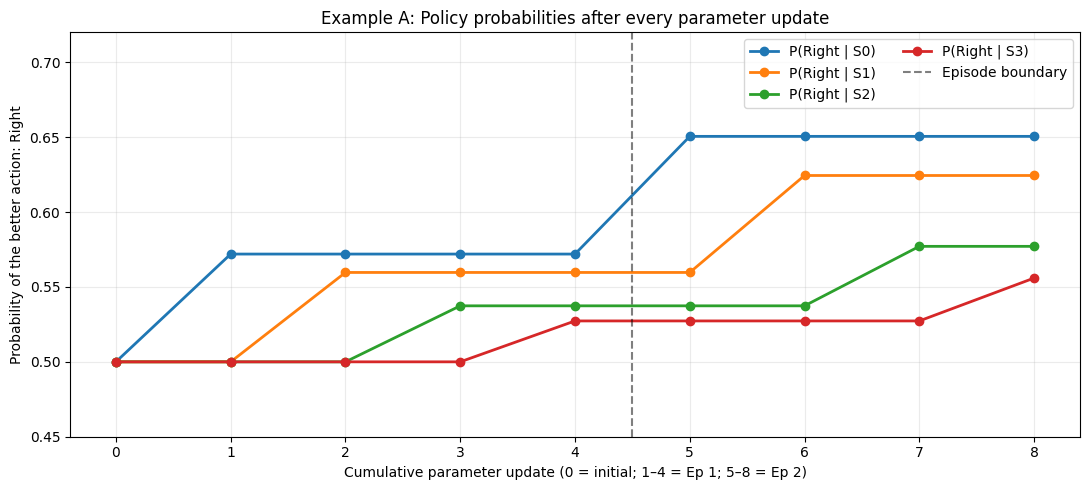

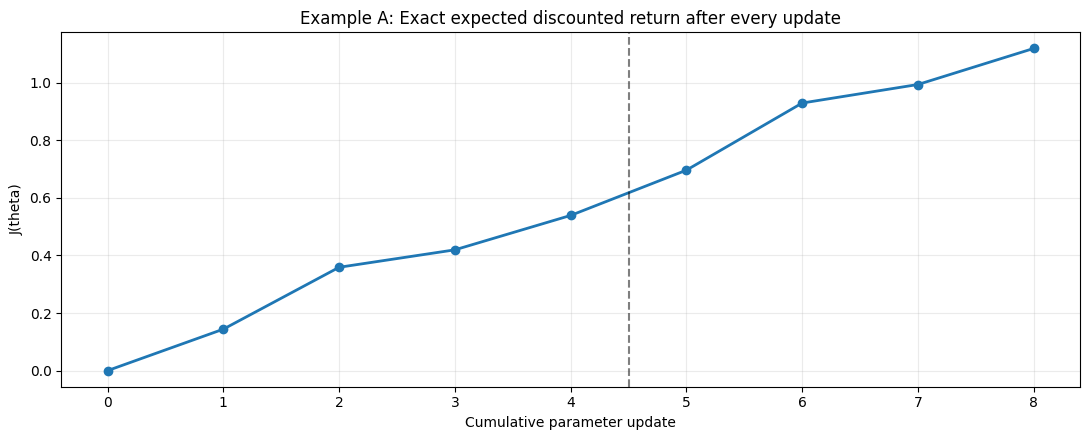

In [3]:
progress_df_2 = pd.DataFrame(progress_2)
plt.figure(figsize=(11,5))
for s in STATES:
    plt.plot(progress_df_2['Update'], progress_df_2[s], marker='o', linewidth=2,
             label=f'P(Right | {s})')
plt.axvline(4.5, color='black', linestyle='--', alpha=.5, label='Episode boundary')
plt.title('Example A: Policy probabilities after every parameter update')
plt.xlabel('Cumulative parameter update (0 = initial; 1–4 = Ep 1; 5–8 = Ep 2)')
plt.ylabel('Probability of the better action: Right')
plt.xticks(range(9)); plt.ylim(.45, .72)
plt.grid(alpha=.25); plt.legend(ncol=2); plt.tight_layout(); plt.show()

plt.figure(figsize=(11,4.5))
plt.plot(progress_df_2['Update'], progress_df_2['J'], marker='o', linewidth=2)
plt.axvline(4.5, color='black', linestyle='--', alpha=.5)
plt.title('Example A: Exact expected discounted return after every update')
plt.xlabel('Cumulative parameter update'); plt.ylabel('J(theta)')
plt.xticks(range(9)); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

---
# Example B — Four available actions (Up, Down, Left, Right)

## 9. Define a five-state, four-action environment

There are still **five visited states and four decisions**, but **at every decision state** the agent now chooses among **four available actions**:

$$\boxed{\mathcal A=\{\mathrm{Up},\mathrm{Down},\mathrm{Left},\mathrm{Right}\}}.$$

A transition always moves $S_t\rightarrow S_{t+1}$ for clarity. The action changes the reward:

| State | Up | Down | Left | Right | Best action |
|---|---:|---:|---:|---:|---|
| $S_0$ | −1 | −1 | −1 | **+1** | Right |
| $S_1$ | **+2** | −2 | −2 | −2 | Up |
| $S_2$ | −1 | −1 | −1 | **+1** | Right |
| $S_3$ | −2 | **+3** | −2 | −2 | Down |
| $S_4$ | Terminal | Terminal | Terminal | Terminal | None |

The reward table is a **teaching example**, not a physical gridworld. The sampled episodes below are possible trajectories, chosen so that each gradient can be checked manually.

The policy now has **four logits per state**: $z_i=[z_{i,U},z_{i,D},z_{i,L},z_{i,R}]$. Set $z_i=[0,0,0,0]$ initially, so each action has probability $0.25$.

## 10. Derive the four-action softmax log-policy gradient

The four action probabilities come from **softmax**:

$$\boxed{\pi_\theta(a=j\mid S_i)=p_{ij}=\frac{e^{z_{ij}}}{\sum_{k=1}^{4}e^{z_{ik}}}}.$$

Taking the logarithm gives $\log\pi_\theta(a\mid S_i)=z_{ia}-\log\bigl(\sum_ke^{z_{ik}}\bigr)$.

Differentiate with respect to any one logit $z_{ij}$:

$$\boxed{\frac{\partial\log\pi_\theta(a\mid S_i)}{\partial z_{ij}}=\mathbf1[j=a]-p_{ij}}.$$

The **four-component gradient vector** is therefore

$$\boxed{\nabla_{z_i}\log\pi_\theta(a\mid S_i)=\mathbf e_a-\mathbf p_i},\quad \mathbf p_i=[p_U,p_D,p_L,p_R].$$

For **Right** at an initially uniform policy:

$$\mathbf e_R=[0,0,0,1],\quad \mathbf p_i=[.25,.25,.25,.25],\quad \boxed{\mathbf e_R-\mathbf p_i=[-.25,-.25,-.25,+.75]}.$$

For **Up**: $\mathbf e_U-\mathbf p_i=[+.75,-.25,-.25,-.25]$. For Left or Down, place $+.75$ in that action's position and $-.25$ in all others.

**Full-network gradient:** If logits are outputs $z_j(s;\theta)$ of a neural network, use the chain rule

$$\nabla_\theta\log\pi_\theta(a\mid s)=\sum_{j=1}^4(\mathbf1[j=a]-\pi_\theta(j\mid s))\nabla_\theta z_j(s;\theta).$$

For this handwritten calculation the logits **are** the trainable parameters, so no additional network derivatives are needed. Updating one selected action's log probability changes **all four logits**, hence all four action probabilities in that state.

### 10.1 Read the vector gradient without memorizing a derivative

The action order throughout Example B is **[Up, Down, Left, Right]**. The one-hot vector $\mathbf e_a$ has a single 1 for the sampled action and 0 elsewhere.

| Chosen action | One-hot $\mathbf e_a$ | Gradient at initially uniform policy $\mathbf e_a-[0.25,0.25,0.25,0.25]$ |
|---|---|---|
| Up | $[1,0,0,0]$ | $[+0.75,-0.25,-0.25,-0.25]$ |
| Down | $[0,1,0,0]$ | $[-0.25,+0.75,-0.25,-0.25]$ |
| Left | $[0,0,1,0]$ | $[-0.25,-0.25,+0.75,-0.25]$ |
| Right | $[0,0,0,1]$ | $[-0.25,-0.25,-0.25,+0.75]$ |

For $c_t=\alpha\gamma^tG_t$, the **complete one-line vector update** is $\boxed{\mathbf z_i^{new}=\mathbf z_i^{old}+c_t(\mathbf e_{A_t}-\mathbf p_i)}$. For **positive** $G_t$ it tends to raise the selected action's logit relative to others; for **negative** $G_t$ it moves the other way. Probabilities must be recalculated with softmax afterward.

## 11. Example B — Episode 1 (four different actions)

$$S_0\xrightarrow{R,+1}S_1\xrightarrow{U,+2}S_2\xrightarrow{R,+1}S_3\xrightarrow{D,+3}S_4.$$

**Returns (one calculation per line):**  
**$t=3$:** $G_3=R_4=3$.  
**$t=2$:** $G_2=R_3+0.9G_3=1+0.9(3.0000)=3.7000$.  
**$t=1$:** $G_1=R_2+0.9G_2=2+0.9(3.7000)=5.3300$.  
**$t=0$:** $G_0=R_1+0.9G_1=1+0.9(5.3300)=5.7970$.

### 11.1 Work through the first four-action update in detail (time $t=0$)

**Initial probabilities:** $\mathbf p_0=[0.25,0.25,0.25,0.25]$; **sampled action:** Right $\Rightarrow \mathbf e_R=[0,0,0,1]$.

**Gradient:** $\mathbf g_0=\mathbf e_R-\mathbf p_0=[0,0,0,1]-[0.25,0.25,0.25,0.25]=[-0.25,-0.25,-0.25,+0.75]$.

**Coefficient:** $c_0=0.1(0.9)^0(5.797)=0.57970$.

**Logit change:** $\Delta\mathbf z_0=0.57970[-0.25,-0.25,-0.25,+0.75]=[-0.144925,-0.144925,-0.144925,+0.434775]$.

**New logits:** $\mathbf z_0^{new}=[0,0,0,0]+\Delta\mathbf z_0=[-0.144925,-0.144925,-0.144925,+0.434775]$.

**New Right probability:** $P(R\mid S_0)=\frac{e^{0.434775}}{3e^{-0.144925}+e^{0.434775}}\approx0.3731$.

**New other probabilities:** $P(U)=P(D)=P(L)=\frac{e^{-0.144925}}{3e^{-0.144925}+e^{0.434775}}\approx0.2090$.

**Interpretation:** In **one** update, the selected Right action rises from $0.25$ to about $0.3731$, and all three unselected actions fall from $0.25$ to about $0.2090$.

**One-line updates per state:** Order of vector components is **[Up, Down, Left, Right]**; use $c_t=\alpha\gamma^tG_t$, $\Delta z_t=c_t(\mathbf e_{A_t}-\mathbf p_t)$, and $z_t^{new}=z_t^{old}+\Delta z_t$.  
**$t=0$, Right:** $c_0=0.1(1.000)(5.797)=0.57970$; $\Delta z_0=[-0.1449, -0.1449, -0.1449, +0.4348]$; $z_0^{new}=[-0.1449, -0.1449, -0.1449, +0.4348]$.  
**$t=1$, Up:** $c_1=0.1(0.900)(5.330)=0.47970$; $\Delta z_1=[+0.3598, -0.1199, -0.1199, -0.1199]$; $z_1^{new}=[+0.3598, -0.1199, -0.1199, -0.1199]$.  
**$t=2$, Right:** $c_2=0.1(0.810)(3.700)=0.29970$; $\Delta z_2=[-0.0749, -0.0749, -0.0749, +0.2248]$; $z_2^{new}=[-0.0749, -0.0749, -0.0749, +0.2248]$.  
**$t=3$, Down:** $c_3=0.1(0.729)(3.000)=0.21870$; $\Delta z_3=[-0.0547, +0.1640, -0.0547, -0.0547]$; $z_3^{new}=[-0.0547, +0.1640, -0.0547, -0.0547]$.

All four rows start with $\mathbf p_t=[0.25,0.25,0.25,0.25]$ in Episode 1, because their four state logit vectors are independent and initially zero.

### 11.2 Convert each updated logit vector to a new probability (Episode 1)  
  
For each row, exponentiate the preferred action’s logit and divide by the sum of **all four** exponentials; the other probabilities follow from the same denominator.  
**$t=0$, Right:** $P(Right\mid S_0)=e^{0.43478}/\sum_{k=1}^4e^{z_{0k}}=1.54462/4.13988=0.37311$.  
**$t=1$, Up:** $P(Up\mid S_1)=e^{0.35978}/\sum_{k=1}^4e^{z_{1k}}=1.43301/4.09397=0.35003$.  
**$t=2$, Right:** $P(Right\mid S_2)=e^{0.22478}/\sum_{k=1}^4e^{z_{2k}}=1.25204/4.03548=0.31026$.  
**$t=3$, Down:** $P(Down\mid S_3)=e^{0.16403}/\sum_{k=1}^4e^{z_{3k}}=1.17824/4.01862=0.29320$.  
  
**All four probabilities, before and after Episode 1** (order: Up, Down, Left, Right):  
  
| $t$ | Selected action | Before: [Up, Down, Left, Right] | After: [Up, Down, Left, Right] |
|---:|---|---|---|
| 0 | Right | $[+0.2500,\ +0.2500,\ +0.2500,\ +0.2500]$ | $[+0.2090,\ +0.2090,\ +0.2090,\ +0.3731]$ |
| 1 | Up | $[+0.2500,\ +0.2500,\ +0.2500,\ +0.2500]$ | $[+0.3500,\ +0.2167,\ +0.2167,\ +0.2167]$ |
| 2 | Right | $[+0.2500,\ +0.2500,\ +0.2500,\ +0.2500]$ | $[+0.2299,\ +0.2299,\ +0.2299,\ +0.3103]$ |
| 3 | Down | $[+0.2500,\ +0.2500,\ +0.2500,\ +0.2500]$ | $[+0.2356,\ +0.2932,\ +0.2356,\ +0.2356]$ |  
  
The probabilities of the best action rose at every state because this first sampled episode selected each state’s best action and obtained positive returns.

## 12. Example B — Episode 2 (four other selected actions)

Generate the second episode using the **updated probabilities**. Suppose the agent now samples **Up, Left, Down, Right**:

$$S_0\xrightarrow{U,-1}S_1\xrightarrow{L,-2}S_2\xrightarrow{D,-1}S_3\xrightarrow{R,-2}S_4.$$

**Returns (one calculation per line):**  
**$t=3$:** $G_3=R_4=-2$.  
**$t=2$:** $G_2=R_3+0.9G_3=-1+0.9(-2.0000)=-2.8000$.  
**$t=1$:** $G_1=R_2+0.9G_2=-2+0.9(-2.8000)=-4.5200$.  
**$t=0$:** $G_0=R_1+0.9G_1=-1+0.9(-4.5200)=-5.0680$.

### 12.1 Detailed second-episode update at $S_0$ (selected Up)

**Current probabilities:** $\mathbf p_0\approx[0.20896,0.20896,0.20896,0.37311]$; **one-hot for Up:** $\mathbf e_U=[1,0,0,0]$.

**Gradient:** $\mathbf g_0=\mathbf e_U-\mathbf p_0\approx[+0.79104,-0.20896,-0.20896,-0.37311]$.

**Coefficient:** $c_0=0.1(0.9)^0(-5.068)=-0.50680$.

**Logit change:** $\Delta\mathbf z_0=c_0\mathbf g_0\approx[-0.4009,+0.1059,+0.1059,+0.1891]$.

**New logits:** $\mathbf z_0^{new}\approx[-0.1449,-0.1449,-0.1449,+0.4348]+\Delta\mathbf z_0=[-0.5458,-0.0390,-0.0390,+0.6239]$.

**New probabilities:** $\mathbf p_0^{new}=\operatorname{softmax}(\mathbf z_0^{new})\approx[0.1326,0.2201,0.2201,0.4271]$.

**What changed?** The negatively rewarded Up action dropped from $\approx0.2090$ to $\approx0.1326$; Right rose from $\approx0.3731$ to $\approx0.4271$. Both **signs** in $c_0\mathbf g_0$ are needed to understand that result.

**Gradient and parameter updates:** Each line gives the **current four probabilities**, the signed coefficient $c_t=0.1(0.9)^tG_t$, the four-logit gradient $\mathbf e_{A_t}-\mathbf p_t$, and the new logits.  
**$t=0$, Up:** $p_0=[+0.2090, +0.2090, +0.2090, +0.3731]$; $c_0=-0.50680$; $\nabla\log\pi=[+0.7910, -0.2090, -0.2090, -0.3731]$; $\Delta z_0=[-0.4009, +0.1059, +0.1059, +0.1891]$; $z_t^{new}=[-0.5458, -0.0390, -0.0390, +0.6239]$.  
**$t=1$, Left:** $p_1=[+0.3500, +0.2167, +0.2167, +0.2167]$; $c_1=-0.40680$; $\nabla\log\pi=[-0.3500, -0.2167, +0.7833, -0.2167]$; $\Delta z_1=[+0.1424, +0.0881, -0.3187, +0.0881]$; $z_t^{new}=[+0.5022, -0.0318, -0.4386, -0.0318]$.  
**$t=2$, Down:** $p_2=[+0.2299, +0.2299, +0.2299, +0.3103]$; $c_2=-0.22680$; $\nabla\log\pi=[-0.2299, +0.7701, -0.2299, -0.3103]$; $\Delta z_2=[+0.0521, -0.1747, +0.0521, +0.0704]$; $z_t^{new}=[-0.0228, -0.2496, -0.0228, +0.2951]$.  
**$t=3$, Right:** $p_3=[+0.2356, +0.2932, +0.2356, +0.2356]$; $c_3=-0.14580$; $\nabla\log\pi=[-0.2356, -0.2932, -0.2356, +0.7644]$; $\Delta z_3=[+0.0344, +0.0427, +0.0344, -0.1114]$; $z_t^{new}=[-0.0203, +0.2068, -0.0203, -0.1661]$.

**Interpretation:** All four actions sampled in Episode 2 receive negative returns. REINFORCE reduces their selected-action probabilities. Since the better action is **different** from the selected one at each state, the probability of the better action increases as a consequence of the softmax update. In general, a negative return means a sampled action is discouraged *relative to the zero-return baseline*; adding a suitable baseline can reduce variance.

### 12.2 Verify all four new policies after Episode 2  
  
Every probability below is computed using **the updated four-logit vector in its own state**; it is not an independent sigmoid for each action.  
**$t=0$, Up:** $\mathbf z_0^{new}=[-0.5458,\ -0.0390,\ -0.0390,\ +0.6239]$ $\Rightarrow$ $\mathbf p_0^{new}=[+0.1326,\ +0.2201,\ +0.2201,\ +0.4271]$; $P(Up)=0.13261$; $P(Right\mid S_0)=0.42713$.  
**$t=1$, Left:** $\mathbf z_1^{new}=[+0.5022,\ -0.0318,\ -0.4386,\ -0.0318]$ $\Rightarrow$ $\mathbf p_1^{new}=[+0.3902,\ +0.2288,\ +0.1523,\ +0.2288]$; $P(Left)=0.15230$; $P(Up\mid S_1)=0.39018$.  
**$t=2$, Down:** $\mathbf z_2^{new}=[-0.0228,\ -0.2496,\ -0.0228,\ +0.2951]$ $\Rightarrow$ $\mathbf p_2^{new}=[+0.2397,\ +0.1911,\ +0.2397,\ +0.3295]$; $P(Down)=0.19108$; $P(Right\mid S_2)=0.32945$.  
**$t=3$, Right:** $\mathbf z_3^{new}=[-0.0203,\ +0.2068,\ -0.0203,\ -0.1661]$ $\Rightarrow$ $\mathbf p_3^{new}=[+0.2428,\ +0.3047,\ +0.2428,\ +0.2098]$; $P(Right)=0.20983$; $P(Down\mid S_3)=0.30465$.  
  
**Before and after Episode 2**, in the fixed order [Up, Down, Left, Right]:  
  
| $t$ | Selected action | Before: [Up, Down, Left, Right] | After: [Up, Down, Left, Right] |
|---:|---|---|---|
| 0 | Up | $[+0.2090,\ +0.2090,\ +0.2090,\ +0.3731]$ | $[+0.1326,\ +0.2201,\ +0.2201,\ +0.4271]$ |
| 1 | Left | $[+0.3500,\ +0.2167,\ +0.2167,\ +0.2167]$ | $[+0.3902,\ +0.2288,\ +0.1523,\ +0.2288]$ |
| 2 | Down | $[+0.2299,\ +0.2299,\ +0.2299,\ +0.3103]$ | $[+0.2397,\ +0.1911,\ +0.2397,\ +0.3295]$ |
| 3 | Right | $[+0.2356,\ +0.2932,\ +0.2356,\ +0.2356]$ | $[+0.2428,\ +0.3047,\ +0.2428,\ +0.2098]$ |  
  
Because **each action selected in Episode 2 was worse than the preferred action and its return was negative**, the probability of that selected action decreases; the better action becomes more likely. This pattern is specific to these two deliberately selected trajectories.

## 13. Example B — Run the updates and plot all intermediate policies

The exact expected return is

$$\boxed{J(\theta)=\sum_{t=0}^{3}\gamma^t\sum_{a\in\{U,D,L,R\}}\pi_\theta(a\mid S_t)r(S_t,a)}.$$

The best actions are **Right, Up, Right, Down**, respectively. We'll plot each state's better-action probability after **every one of the eight state-specific updates**, then plot expected return $J(\theta)$ on the same update axis.

### Calculate the exact expected return by hand (Example B)

**Initial expected immediate rewards:** $E[R_1]=0.25(-1-1-1+1)=-0.5$; $E[R_2]=0.25(2-2-2-2)=-1$; $E[R_3]=-0.5$; $E[R_4]=0.25(-2+3-2-2)=-0.75$.

**Initial expected discounted return:** $J_0=-0.5+0.9(-1)+0.81(-0.5)+0.729(-0.75)=-2.35175$.

**After Episode 1:** $J_1=\sum_{t=0}^3(0.9)^t\sum_a P_1(a\mid S_t)r(S_t,a)\approx -1.49037$.

**After Episode 2:** $J_2=\sum_{t=0}^3(0.9)^t\sum_a P_2(a\mid S_t)r(S_t,a)\approx -1.16489$.

This exact $J$ is available **only because this example specifies every action's reward and the transitions**. The REINFORCE training loop does **not** calculate $J$; it learns from sampled $G_t$ values. The **observed reward of an episode** and the **expected return of a policy** are different quantities.

In [4]:
ACTIONS_4 = ['Up', 'Down', 'Left', 'Right']
BEST_4 = ['Right', 'Up', 'Right', 'Down']
REWARDS_4 = np.array([
    [-1, -1, -1, +1],
    [+2, -2, -2, -2],
    [-1, -1, -1, +1],
    [-2, +3, -2, -2],
], dtype=float)
EPISODES_4 = [
    ('Episode 1', ['Right', 'Up', 'Right', 'Down']),
    ('Episode 2', ['Up', 'Left', 'Down', 'Right']),
]


def exact_objective_four(logits):
    expected_rewards = np.sum(softmax(logits) * REWARDS_4, axis=1)
    return float(np.dot(GAMMA ** np.arange(4), expected_rewards))


def four_probability_record(logits, update, label):
    p = softmax(logits)
    return {'Update':update, 'Stage':label, 'J':exact_objective_four(logits),
            **{f'S{i}':float(p[i, ACTIONS_4.index(BEST_4[i])]) for i in range(4)}}

logits_4 = np.zeros((4,4))
logits_timeline_4 = [logits_4.copy()]
log_4 = []
progress_4 = [four_probability_record(logits_4, 0, 'Initial')]
logits_after_ep1 = None
for ep, actions in EPISODES_4:
    rewards = [REWARDS_4[t, ACTIONS_4.index(a)] for t, a in enumerate(actions)]
    G = discounted_returns(rewards)
    for t, (a, reward) in enumerate(zip(actions, rewards)):
        p_before = softmax(logits_4[t])
        one_hot = np.eye(4)[ACTIONS_4.index(a)]
        gradient = one_hot - p_before
        coefficient = ALPHA * GAMMA**t * G[t]
        delta_logits = coefficient * gradient
        logits_4[t] += delta_logits
        p_after = softmax(logits_4[t])
        log_4.append({'Episode':ep, 't':t, 'Action':a, 'Reward':reward,
                      'Gt':G[t], 'coefficient':coefficient,
                      'p(selected) before':p_before[ACTIONS_4.index(a)],
                      'p(selected) after':p_after[ACTIONS_4.index(a)],
                      'p(best) after':p_after[ACTIONS_4.index(BEST_4[t])]})
        progress_4.append(four_probability_record(logits_4, len(progress_4), f'{ep}: t={t}'))
        logits_timeline_4.append(logits_4.copy())
    if ep == 'Episode 1':
        logits_after_ep1 = logits_4.copy()

print('Four-action update table (all calculations correspond to the manual example):')
display(pd.DataFrame(log_4).round(5))
print('Probability of each action, before training / after Episode 1 / after Episode 2:')
for stage, z in [('Initial', np.zeros((4,4))), ('After E1', logits_after_ep1), ('After E2', logits_4)]:
    print('\n' + stage)
    display(pd.DataFrame(softmax(z), index=STATES, columns=ACTIONS_4).round(4))
assert all(np.diff([r['J'] for r in progress_4]) > 0)

Four-action update table (all calculations correspond to the manual example):


,Episode,t,Action,Reward,Gt,coefficient,p(selected) before,p(selected) after,p(best) after
0,Episode 1,0,Right,1.0,5.797,0.5797,0.25000,0.37311,0.37311
1,Episode 1,1,Up,2.0,5.330,0.4797,0.25000,0.35003,0.35003
2,Episode 1,2,Right,1.0,3.700,0.2997,0.25000,0.31026,0.31026
3,Episode 1,3,Down,3.0,3.000,0.2187,0.25000,0.29320,0.29320
4,Episode 2,0,Up,-1.0,-5.068,-0.5068,0.20896,0.13261,0.42713
5,Episode 2,1,Left,-2.0,-4.520,-0.4068,0.21666,0.15230,0.39018
6,Episode 2,2,Down,-1.0,-2.800,-0.2268,0.22991,0.19108,0.32945
7,Episode 2,3,Right,-2.0,-2.000,-0.1458,0.23560,0.20983,0.30465


Probability of each action, before training / after Episode 1 / after Episode 2:

Initial


,Up,Down,Left,Right
S0,0.25,0.25,0.25,0.25
S1,0.25,0.25,0.25,0.25
S2,0.25,0.25,0.25,0.25
S3,0.25,0.25,0.25,0.25



After E1


,Up,Down,Left,Right
S0,0.2090,0.2090,0.2090,0.3731
S1,0.3500,0.2167,0.2167,0.2167
S2,0.2299,0.2299,0.2299,0.3103
S3,0.2356,0.2932,0.2356,0.2356



After E2


,Up,Down,Left,Right
S0,0.1326,0.2201,0.2201,0.4271
S1,0.3902,0.2288,0.1523,0.2288
S2,0.2397,0.1911,0.2397,0.3295
S3,0.2428,0.3047,0.2428,0.2098


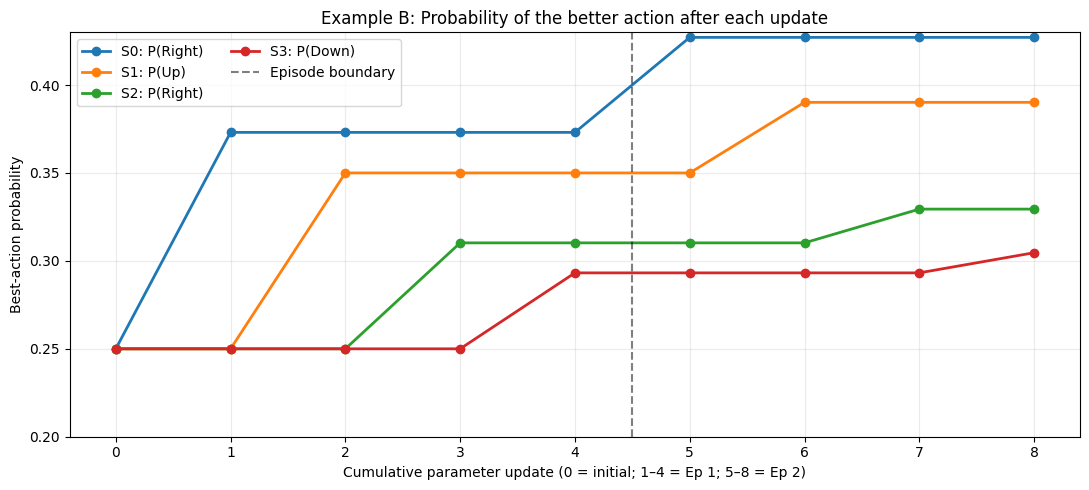

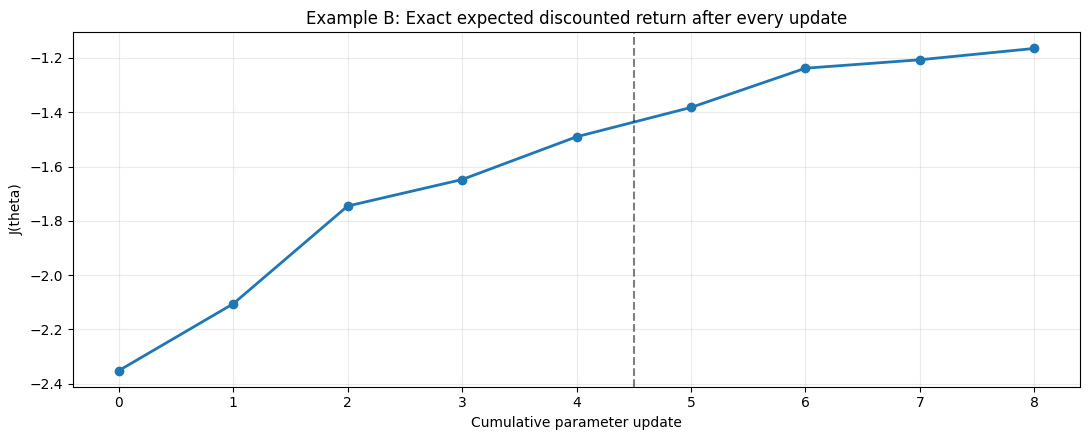

In [5]:
progress_df_4 = pd.DataFrame(progress_4)
plt.figure(figsize=(11,5))
for t in range(4):
    plt.plot(progress_df_4['Update'], progress_df_4[f'S{t}'], '-o', linewidth=2,
             label=f'{STATES[t]}: P({BEST_4[t]})')
plt.axvline(4.5, color='black', linestyle='--', alpha=.5, label='Episode boundary')
plt.title('Example B: Probability of the better action after each update')
plt.xlabel('Cumulative parameter update (0 = initial; 1–4 = Ep 1; 5–8 = Ep 2)')
plt.ylabel('Best-action probability')
plt.xticks(range(9)); plt.ylim(.20,.43)
plt.grid(alpha=.25); plt.legend(ncol=2); plt.tight_layout(); plt.show()

plt.figure(figsize=(11,4.5))
plt.plot(progress_df_4['Update'], progress_df_4['J'], '-o', linewidth=2)
plt.axvline(4.5, color='black', linestyle='--', alpha=.5)
plt.title('Example B: Exact expected discounted return after every update')
plt.xlabel('Cumulative parameter update'); plt.ylabel('J(theta)')
plt.xticks(range(9)); plt.grid(alpha=.25); plt.tight_layout(); plt.show()

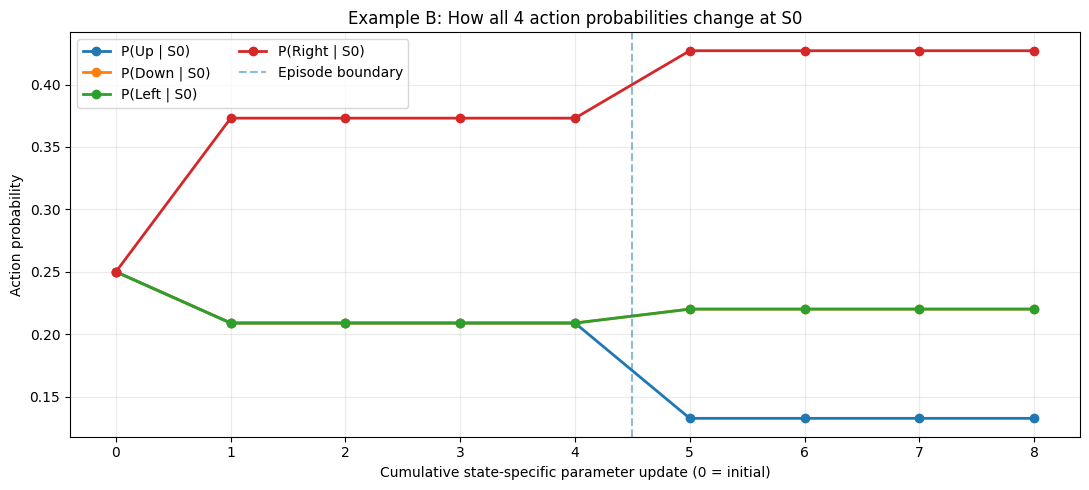

In [6]:
# Extra diagnostic: changes to all four action probabilities at S0 after EVERY update.
# The policy at S0 changes only when its own parameters are updated (at updates 1 and 5).
policy_history_4 = np.array([softmax(snapshot[0]) for snapshot in logits_timeline_4])
plt.figure(figsize=(11, 5))
for a_i, a_name in enumerate(ACTIONS_4):
    plt.plot(range(9), policy_history_4[:, a_i], '-o', linewidth=2,
             label=f'P({a_name} | S0)')
plt.axvline(4.5, linestyle='--', alpha=.5, label='Episode boundary')
plt.xticks(range(9))
plt.xlabel('Cumulative state-specific parameter update (0 = initial)')
plt.ylabel('Action probability')
plt.title('Example B: How all 4 action probabilities change at S0')
plt.grid(alpha=.25);plt.legend(ncol=2);plt.tight_layout();plt.show()

assert len(logits_timeline_4)==9
assert np.allclose(policy_history_4.sum(axis=1), 1.0)

## 14. Verify the two-episode hand calculations

A small verification cell checks **return recursion**, **valid probabilities**, **gradient signs**, and **improving exact expected return for the two deliberately selected trajectories**. This does not claim monotonicity for arbitrary trajectories.

In [7]:
assert np.allclose(discounted_returns([1,2,1,3]), [5.797,5.33,3.7,3.0])
assert np.allclose(discounted_returns([-1,-2,-1,-2]), [-5.068,-4.52,-2.8,-2.0])
assert np.allclose(np.sum(softmax(logits_4),axis=1), np.ones(4))
assert np.allclose(np.sum(softmax(logits_after_ep1),axis=1), np.ones(4))
assert len(log_2) == 8 and len(log_4) == 8
assert all(progress_df_2['J'].diff().iloc[1:] > 0)
assert all(progress_df_4['J'].diff().iloc[1:] > 0)
assert (softmax(logits_4).max(axis=1) <= 1).all()
print('PASS: returns, probability normalization, all eight updates in each example, and expected-return improvement for both chosen two-episode trajectories.')

PASS: returns, probability normalization, all eight updates in each example, and expected-return improvement for both chosen two-episode trajectories.


### 14.1 Quick manual checks you can repeat without running code

| Check | Calculation | Expected result |
|---|---|---|
| Return in Example A | $G_0=1+0.9[2+0.9(1+0.9\cdot3)]$ | $5.797$ |
| Initial sigmoid | $\sigma(0)=1/(1+e^0)$ | $0.5$ |
| Initial softmax | $e^0/(4e^0)$ | $0.25$ |
| Initial Right gradient (4 actions) | $[0,0,0,1]-[.25,.25,.25,.25]$ | $[-.25,-.25,-.25,.75]$ |
| Softmax validity | $\sum_{a\in\mathcal A}\pi(a\mid s)$ | $1$ |
| On-policy sampling | Sample Episode 2 using policy **after** Episode 1 | Updated probabilities |

**Important wording:** A plot of *every parameter update* is not a plot of **online updates within an unfinished episode**. All four state-specific contributions are computed after the episode ends; our states use independent parameters, which makes it possible to display those contributions separately. When using a **shared neural network**, collect all log-probabilities first and make one gradient update using their sum.

---
# Beyond two hand-picked episodes: stochastic REINFORCE

## 15. Train using randomly sampled trajectories (four-action example)

The previous examples fixed their trajectories **for transparent arithmetic**. Actual REINFORCE samples actions from the current policy, then uses the observed complete return to update parameters. We now run **800 episodes** with the same four-action reward table; each episode is newly sampled.

We show **three different quantities**:

1. **Sampled episode return:** Noisy because the agent explores.
2. **Rolling mean of sampled returns:** Smoother estimate of recent performance.
3. **Exact expected return:** Computable only because this teaching environment's rewards and transitions are explicitly known.

A real environment usually does **not** provide an exact formula for $J(\theta)$.

In [8]:
rng = np.random.default_rng(SEED)
train_logits = np.zeros((4,4))
N_EPISODES = 800
TRAIN_ALPHA = 0.04
sample_returns = []
exact_J_history = [exact_objective_four(train_logits)]
best_prob_history = [np.array([softmax(train_logits)[t,ACTIONS_4.index(BEST_4[t])] for t in range(4)])]

for episode in range(N_EPISODES):
    # First sample one *complete* on-policy episode with fixed parameters.
    p = softmax(train_logits)
    sampled_actions = [int(rng.choice(4,p=p[t])) for t in range(4)]
    rewards = [REWARDS_4[t,a] for t,a in enumerate(sampled_actions)]
    returns_t = discounted_returns(rewards)
    sample_returns.append(returns_t[0])
    # Because parameters are independent for each state, these four row updates
    # equal one aggregated gradient step for the full 4x4 parameter matrix.
    full_gradient = np.zeros_like(train_logits)
    for t,a in enumerate(sampled_actions):
        full_gradient[t] += (GAMMA**t)*returns_t[t]*(np.eye(4)[a]-p[t])
    train_logits += TRAIN_ALPHA * full_gradient
    new_p = softmax(train_logits)
    exact_J_history.append(exact_objective_four(train_logits))
    best_prob_history.append(np.array([new_p[t,ACTIONS_4.index(BEST_4[t])] for t in range(4)]))

print('Initial exact J:', round(exact_J_history[0],4))
print('Final exact J:  ', round(exact_J_history[-1],4))
print('Final action probabilities:')
display(pd.DataFrame(softmax(train_logits), index=STATES, columns=ACTIONS_4).round(4))

Initial exact J: -2.3518
Final exact J:   5.697
Final action probabilities:


,Up,Down,Left,Right
S0,0.0033,0.0029,0.0026,0.9911
S1,0.9936,0.0018,0.0023,0.0023
S2,0.0080,0.0064,0.0062,0.9794
S3,0.0026,0.9929,0.0021,0.0024


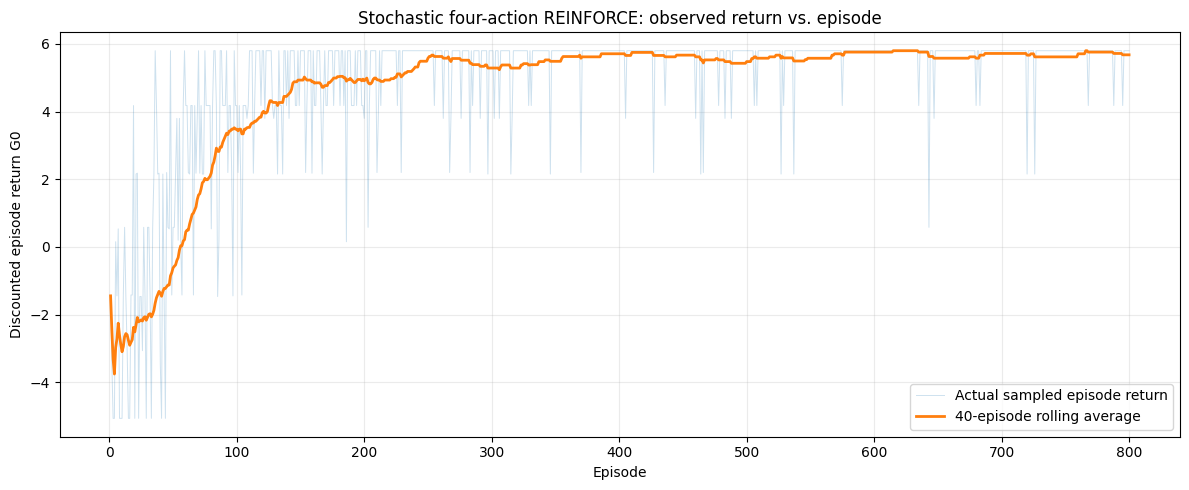

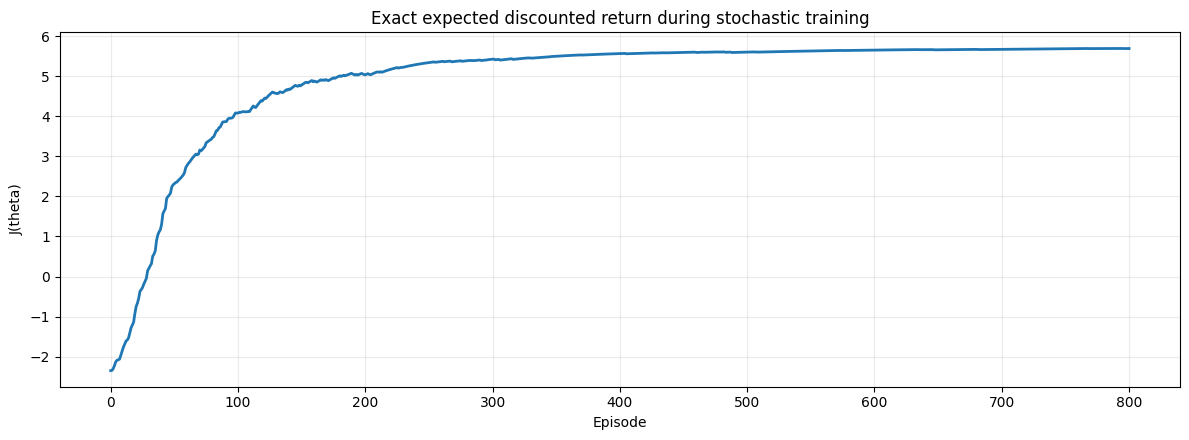

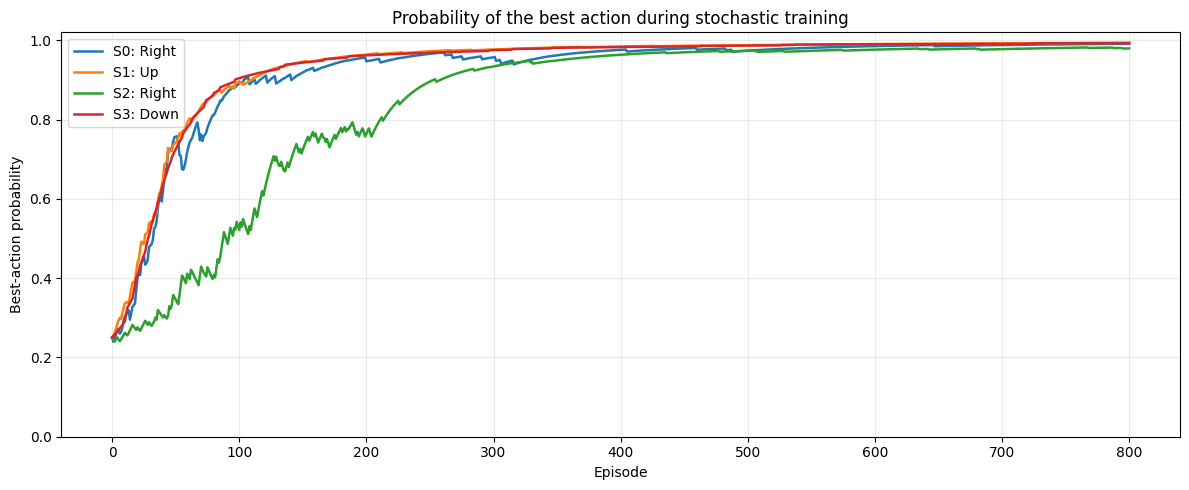

In [9]:
rolling_window = 40
rolling_reward = pd.Series(sample_returns).rolling(rolling_window, min_periods=1).mean()
plt.figure(figsize=(12,5))
plt.plot(np.arange(1,N_EPISODES+1), sample_returns, alpha=.22, linewidth=.7,
         label='Actual sampled episode return')
plt.plot(np.arange(1,N_EPISODES+1), rolling_reward, linewidth=2,
         label=f'{rolling_window}-episode rolling average')
plt.title('Stochastic four-action REINFORCE: observed return vs. episode')
plt.xlabel('Episode'); plt.ylabel('Discounted episode return G0')
plt.grid(alpha=.25); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(12,4.5))
plt.plot(range(N_EPISODES+1), exact_J_history, linewidth=2)
plt.title('Exact expected discounted return during stochastic training')
plt.xlabel('Episode'); plt.ylabel('J(theta)')
plt.grid(alpha=.25); plt.tight_layout(); plt.show()

plt.figure(figsize=(12,5))
best_prob_history = np.asarray(best_prob_history)
for t in range(4):
    plt.plot(range(N_EPISODES+1), best_prob_history[:,t],
             label=f'{STATES[t]}: {BEST_4[t]}', linewidth=1.8)
plt.title('Probability of the best action during stochastic training')
plt.xlabel('Episode'); plt.ylabel('Best-action probability')
plt.ylim(0,1.02); plt.grid(alpha=.25); plt.legend(); plt.tight_layout(); plt.show()

### Interpreting the three stochastic-training graphs

- **Actual return vs. episode:** Each point is one sampled $G_0$. Its ups and downs are normal; even a strong stochastic policy can draw an unfavorable action.
- **Exact expected $J$ vs. episode:** Evaluates the **current policy**, averaged over possible action sequences using the known toy model. It can occasionally fall; REINFORCE does not guarantee monotonic improvement.
- **Best-action probability vs. episode:** Shows how the policy shifts toward Right/Up/Right/Down as training proceeds. Unlike the hand-picked examples, this trajectory is **truly sampled** with a fixed random seed.

## 16. REINFORCE, vanilla policy gradient, actor–critic, PPO: what changes?

| Method | Gradient weight / learning signal | Main point |
|---|---|---|
| **REINFORCE** | Complete Monte Carlo $G_t$ | Simple and unbiased estimator of the stated objective, but often high variance |
| **REINFORCE with baseline** | $G_t-b(S_t)$ | A state-only baseline reduces variance without biasing the gradient (under standard assumptions) |
| **Actor–critic** | Estimate $\hat A_t$ from learned values | A critic supplies a lower-variance learning signal, possibly with bootstrapping |
| **PPO** | Advantage-weighted clipped probability ratio | Constrains how strongly policy changes during each optimization round |

**Terminology:** “Vanilla policy gradient” often refers to the basic policy-gradient approach and is sometimes used as a synonym for REINFORCE or for an implementation with a baseline. The exact usage varies; the algorithm must be identified from its gradient estimator and update rule.

**Advantage/baseline connection:** $\mathbb E[\nabla_\theta\log\pi_\theta(A_t\mid S_t)b(S_t)]=0$ when the baseline does not depend on the sampled action, so the discounted gradient can use $\gamma^t(G_t-b(S_t))$ in place of $\gamma^t G_t$.

**Practical limitations:** Monte Carlo updates must wait for the episode to finish and can have high variance. A large step size can destabilize learning; policy-gradient methods do not guarantee improvement at *every* sampled update. For continuous actions, use a parameterized density (e.g., Gaussian) rather than a discrete softmax.

### Final formula reference

**Return:** $\boxed{G_t=R_{t+1}+\gamma G_{t+1}}$.

**Policy-gradient identity:** $\boxed{\nabla_\theta J=\mathbb E[\sum_t\gamma^tG_t\nabla_\theta\log\pi_\theta(A_t\mid S_t)]}$.

**REINFORCE update:** $\boxed{\theta\leftarrow\theta+\alpha\sum_t\gamma^tG_t\nabla_\theta\log\pi_\theta(A_t\mid S_t)}$.

**Softmax log-gradient:** $\boxed{\partial\log\pi(a\mid s)/\partial z_j=\mathbf1[j=a]-\pi(j\mid s)}$.

*References for further reading: Sutton & Barto, Reinforcement Learning: An Introduction (2nd ed.), Chapter 13 (Policy Gradient Methods); Williams (1992), Simple statistical gradient-following algorithms for connectionist reinforcement learning.*

## 17. What to remember before implementing REINFORCE with an ANN

1. **Before each episode:** Use the current network to sample actions and save $\log\pi_\theta(A_t\mid S_t)$ for the sampled trajectory.
2. **After the episode:** Compute $G_t$ from the observed rewards, working backward from the terminal reward.
3. **During training:** Build the scalar loss $\boxed{L(\theta)=-\sum_{t=0}^{T-1}\gamma^tG_t\log\pi_\theta(A_t\mid S_t)}$ (returns treated as constants) and **minimize** it with an optimizer.
4. **Next episode:** Sample again from the newly updated policy. REINFORCE is **on-policy**; previously collected trajectories generally should not be reused as though they came from the updated policy without correction.

**Two separate ideas:** An episode contains **four chosen actions** because it has four decisions. The environment in Example B offers **four available actions at each decision**; only one of them is sampled at each step. Updating softmax changes the probabilities of **all four available actions** in the visited state.